In [1]:
import pandas as pd
import matplotlib as plt
import os
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
print("Goodbye Space")

Goodbye Space


In [3]:
df = pd.read_csv("rtd.csv")

In [4]:
# df.shape
# df.columns
# df.info()
# df.describe()

In [5]:
ir = df["Issue Reported"]

print(ir.unique(), "\n")
print(ir.value_counts())

<StringArray>
[           'Stalled Vehicle',               'Crash Urgent',
            'LOOSE LIVESTOCK',          'TRFC HAZD/ DEBRIS',
             'Traffic Hazard',                  'COLLISION',
 'COLLISION/PRIVATE PROPERTY',          'FLEET ACC/ INJURY',
              'Crash Service',      'COLLISION WITH INJURY',
          'COLLISN/ LVNG SCN',           'zSTALLED VEHICLE',
              'BOAT ACCIDENT',               'VEHICLE FIRE',
          'BLOCKED DRIV/ HWY',           'TRAFFIC FATALITY',
                  'AUTO/ PED',         'Traffic Impediment',
         'N / HZRD TRFC VIOL',                'ICY ROADWAY',
            'COLLISN / FTSRA',           'FLEET ACC/ FATAL',
               'OBSTRUCT HWY',                 'HIGH WATER']
Length: 24, dtype: str 

Issue Reported
Traffic Hazard                138183
Crash Urgent                  115853
Crash Service                  63587
COLLISION                      50256
TRFC HAZD/ DEBRIS              37503
COLLISION WITH INJURY        

In [6]:
ih35 = df[df["Address"].str.contains("IH 35", na=False)]

In [7]:
# urgent = df[df["Issue Reported"] == "Crash Urgent"]
urgent = df["Issue Reported"] == "Crash Urgent"

In [8]:
ih35[urgent]

/tmp/ipykernel_2413/188159042.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ih35[urgent]


,Traffic Report ID,Published Date,Issue Reported,Location,Latitude,Longitude,Address,Status,Status Date,Agency
17,7FCDB7BA6DE74B6E007EFE1079540E0228817D26_17096...,2024 Mar 06 02:30:38 AM,Crash Urgent,POINT (-97.696568 30.346648),30.346648,-97.696568,8312 N IH 35 SVRD SB,ARCHIVED,2024 Mar 06 05:10:12 AM,AUSTIN PD
149,508DE84D9E60D0EA4F80173324A7A9CC95DBEDB3_17122...,2024 Apr 04 09:57:57 PM,Crash Urgent,POINT (-97.719288 30.295057),30.295057,-97.719288,3800 N IH 35 UPPER DECK NB,ARCHIVED,2024 Apr 04 11:25:48 PM,AUSTIN PD
213,5F5898E4726001663BA5A126B313B03B1AED3F07_17097...,2024 Mar 06 04:59:46 PM,Crash Urgent,POINT (-97.67169 30.423909),30.423909,-97.671690,13600 N IH 35 SB,ARCHIVED,2024 Mar 06 06:45:25 PM,AUSTIN PD
215,EC10DB9185C9C58A004FA683DD21AFCD16CAD418_17109...,2024 Mar 20 02:29:08 PM,Crash Urgent,POINT (-97.753967 30.213333),30.213333,-97.753967,S IH 35 SVRD SB / E ST ELMO RD,ARCHIVED,2024 Mar 20 05:10:26 PM,AUSTIN PD
289,BA2E8AA59E4161EE5807078F7226C405FDE751A6_15609...,2019 Jun 19 11:26:40 PM,Crash Urgent,POINT (-97.737007 30.256942),30.256942,-97.737007,31-61 N IH 35 NB,ARCHIVED,2019 Jun 20 01:00:05 AM,NaN
...,...,...,...,...,...,...,...,...,...,...
470908,0DCEDD9FF2B9E09E7BF85EEEC8CA731A3D606372_17735...,2026 Mar 14 03:20:33 PM,Crash Urgent,POINT (-97.672546 30.386505),30.386505,-97.672546,12000-12105 N IH 35 SVRD NB,ARCHIVED,2026 Mar 14 05:10:25 PM,AUSTIN PD
470966,7FCDB7BA6DE74B6E007EFE1079540E0228817D26_17735...,2026 Mar 14 11:47:36 PM,Crash Urgent,POINT (-97.731784 30.274747),30.274747,-97.731784,N IH 35 SVRD SB / E 15TH ST,ARCHIVED,2026 Mar 15 01:20:15 AM,AUSTIN PD
471372,AAEAE9503F54F2A5E567D9F98C62923058C68889_17738...,2026 Mar 18 09:36:04 AM,Crash Urgent,POINT (-97.770856 30.189791),30.189791,-97.770856,6600 S IH 35 NB,ARCHIVED,2026 Mar 18 09:45:13 AM,AUSTIN PD
471399,B369414C7CF027CAD9F6D8D9681B1B123DB8477F_17739...,2026 Mar 19 10:06:58 PM,Crash Urgent,POINT (-97.688077 30.35796),30.35796,-97.688077,9300 N IH 35 NB,ARCHIVED,2026 Mar 19 10:35:19 PM,AUSTIN PD


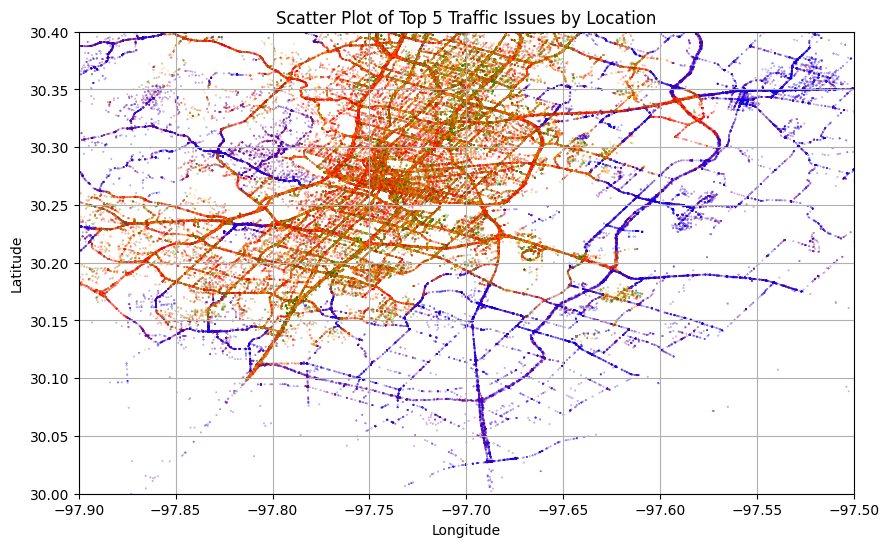

In [9]:
# Get top 5 most common issues
top_issues = df['Issue Reported'].value_counts().head(5).index.tolist()

# Filter dataset to only include these top 5
df_top_issues = df[df['Issue Reported'].isin(top_issues)].copy()
# Assign a color to each issue type

issue_colors = {
    top_issues[0]: 'red',
    top_issues[1]: 'orange',
    top_issues[2]: 'green',
    top_issues[3]: 'blue',
    top_issues[4]: 'purple',
}

# Map color values
df_top_issues['Color'] = df_top_issues['Issue Reported'].map(issue_colors)

# clean
unclean = df[(df["Longitude"].isin([0, "not Austin"])) | (df["Latitude"].isin([0, "Not Austin"]))]
df.drop(unclean.index, inplace=True)

# Convert to numeric, coercing invalid values to NaN
df_top_issues['Longitude'] = pd.to_numeric(df_top_issues['Longitude'], errors='coerce')
df_top_issues['Latitude'] = pd.to_numeric(df_top_issues['Latitude'], errors='coerce')

# Remove rows with NaN coordinates
df_top_issues = df_top_issues.dropna(subset=['Longitude', 'Latitude'])

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df_top_issues['Longitude'], 
    df_top_issues['Latitude'], 
    c=df_top_issues['Color'], 
    alpha=0.5, 
    s=.1
)
plt.title("Scatter Plot of Top 5 Traffic Issues by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.xlim(-97.8-.1, -97.6+.1)
plt.ylim(30.1-.1, 30.3+.1)

plt.grid(True)
plt.show()


